In [1]:
import numpy as np
import pandas as pd
import pygimli as pg
from pygimli.physics import ert
import matplotlib.pyplot as plt
import glob
import os
import matplotlib.patheffects as PathEffects


In [2]:

# figure plotting preferences 

dpi = 200 # resolution
fs = 20 # fontsize


In [3]:
# copy threshold values from profile with borehole

y_th_lamp = np.array(
[1321.4234194980504,
 872.6853829988842,
 721.1252041859406,
 1422.1631935223727,
 667.0783035113924,
 895.2164767611438,
 991.5619339262407]
)

In [4]:
# range of inversion parameters to test 

lam = np.array([1,3,9,
               3,3,
               3,3])

mstart_mult = np.array([1,1,1,
                  1,1,
                  0.1,10])

err_rel = np.array([0.03,0.03,0.03,
                    0.015,0.06,
                    0.03,0.03])    

In [5]:

def invert_w_sensitivity(pn,fn,sensorids,yth,lam,mstart_mult,err_rel):
    
    T_plt_all = []
    R_plt_all = []
    p_f_all = []
    p_uf_all = []
    xth_all = []
    yth_all = []
    contours = []
    
    for j in range(0,len(lam)):
        
        contours_temp = []
        # load raw fata

        data_raw = ert.load(pn+fn) 

        survey_name=fn
        plotmodel=True

        # calculate geometric factor and apparent resistivity if not already in data file

        if data_raw.haveData('k')==False:
            data_raw['k'] = ert.createGeometricFactors(data_raw,numerical=True) # include topo in k calculation

        if data_raw.haveData('rhoa')==False:
            if data_raw.haveData('r')==False:
                data_raw['r'] = data_raw['u']/data_raw['i']
            data_raw['rhoa'] = data_raw['r']*data_raw['k'] 

        # some datasets had problematic cables. if so, remove those data points

        if sensorids is not None:
            data_raw.removeSensorIdx(sensorids)

        mgr = ert.ERTManager(data_raw)

        # inversion parameters

        mgr.inv.inv.setBlockyModel(True)

        data_raw['err'] = ert.estimateError(
        data_raw, 
        absoluteError=0.001, 
        relativeError=err_rel[j] # % noise
        )

        # run inversion

        mod = mgr.invert(
            data_raw,
            lam=lam[j],
            startModel=np.mean(data_raw['rhoa'])*mstart_mult[j],
        )

        # getting chi2, rms error

        chi2 = mgr.inv.inv.getChi2()
        rms = np.sqrt(np.mean(((data_raw['rhoa']-mgr.inv.response)/data_raw['rhoa'])**2))*100

        # plot results

        fig1, ax1 = plt.subplots(1,1,figsize=[13,5])

        ax, cBar = mgr.showResult(
           mod,
            ax=ax1,
            cMap='turbo_r',
            coverage=mgr.coverage(),
            cMin=100,
            cMax=15000,
            orientation='vertical',
        )

        # colorbar

        cBar.set_label('')
        cBar.ax.tick_params(labelsize=fs-4) 
        cBar.ax.set_title(r'$\rho$ ($\Omega$m)'+ '\n',fontsize=fs,rotation=270, y=0.35,x=5)

        # get axis limits and trim figure automatically

        Ex = np.array(data_raw.sensors()).T[0]
        Ey = np.array(data_raw.sensors()).T[1]
        xmin = min(Ex)
        xmax = max(Ex)
        ymin = mgr.paraDomain.yMin()
        ymax = mgr.paraDomain.yMax()
        trim_ymin = ymin + (ymax-ymin)/3
        ax1.set_ylim([trim_ymin,ymax+abs(ymax-ymin)*0.07])
        ax1.set_xlim([xmin,xmax])

        # figure details - electrodes, rms error, axis labels, borehole location

#         ax1.plot(Ex,Ey,'ko')
        txt = ax1.text(xmin+(xmax-xmin)*0.02,trim_ymin+(ymax-trim_ymin)*0.1,'RMSE=%.1f%%'%(rms),color='k',fontsize=fs)
        ax1.tick_params(axis='both', labelsize=fs-4)
        ax1.set_xlabel('X (m)',fontsize=fs)
        ax1.set_ylabel('Z (m)',fontsize=fs)
        
        if j==1: # best estimate model
            
            cs = ax1.tricontour(
                np.array(mgr.paraDomain.cellCenters()).T[0],
                np.array(mgr.paraDomain.cellCenters()).T[1],
                mgr.model,
                levels=[yth[j]],
                colors='k',
                linewidth=3,
                alpha=1,
                zorder=3          
                  )   

        else: # sensitivity analyis results

            cs = ax1.tricontour(
                np.array(mgr.paraDomain.cellCenters()).T[0],
                np.array(mgr.paraDomain.cellCenters()).T[1],
                mgr.model,
                levels=[yth[j]],
                colors='blueviolet',
                linewidth=3,
                alpha=1,
                  ) 

        for collection in cs.collections:
            for path in collection.get_paths():
                contours_temp.append(path.vertices.copy())      

        contours.append(contours_temp)
        
        plt.show()     
    return contours

10/04/26 - 12:47:27 - pyGIMLi - INFO - Cache /Users/teddiherringnew/opt/miniconda3/envs/idgsp-mc/lib/python3.9/site-packages/pygimli/physics/ert/ert.py:createGeometricFactors restored (2.9s x 70): /Users/teddiherringnew/Library/Caches/pygimli/4685734810500315786
10/04/26 - 12:47:27 - pyGIMLi - INFO - Found 2 regions.
10/04/26 - 12:47:27 - pyGIMLi - INFO - Region with smallest marker (1) set to background
10/04/26 - 12:47:27 - Core - WARNING - Region Nr: 1  is background and should not get a model transformation.
10/04/26 - 12:47:27 - Core - WARNING - Region Nr: 1  is background and should not get a model control.
10/04/26 - 12:47:27 - pyGIMLi - INFO - Creating forward mesh from region infos.
10/04/26 - 12:47:27 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
10/04/26 - 12:47:27 - pyGIMLi - INFO - Homogeneous starting model set to: 2627.3123000653964


/var/folders/5z/g4c125y952l233l_4lb9yt6c0000gp/T/ipykernel_21037/2620157793.py:116: UserWarning: The following kwargs were not used by contour: 'linewidth'
  cs = ax1.tricontour(


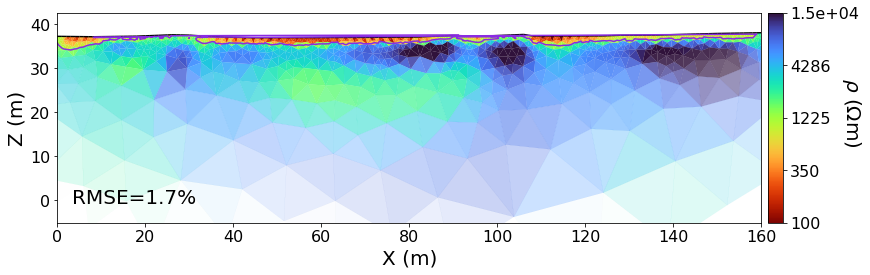

10/04/26 - 12:47:37 - pyGIMLi - INFO - Cache /Users/teddiherringnew/opt/miniconda3/envs/idgsp-mc/lib/python3.9/site-packages/pygimli/physics/ert/ert.py:createGeometricFactors restored (2.9s x 71): /Users/teddiherringnew/Library/Caches/pygimli/4685734810500315786
10/04/26 - 12:47:37 - pyGIMLi - INFO - Found 2 regions.
10/04/26 - 12:47:37 - pyGIMLi - INFO - Region with smallest marker (1) set to background
10/04/26 - 12:47:37 - Core - WARNING - Region Nr: 1  is background and should not get a model transformation.
10/04/26 - 12:47:37 - Core - WARNING - Region Nr: 1  is background and should not get a model control.
10/04/26 - 12:47:37 - pyGIMLi - INFO - Creating forward mesh from region infos.
10/04/26 - 12:47:37 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
10/04/26 - 12:47:37 - pyGIMLi - INFO - Homogeneous starting model set to: 2627.3123000653964


/var/folders/5z/g4c125y952l233l_4lb9yt6c0000gp/T/ipykernel_21037/2620157793.py:103: UserWarning: The following kwargs were not used by contour: 'linewidth'
  cs = ax1.tricontour(


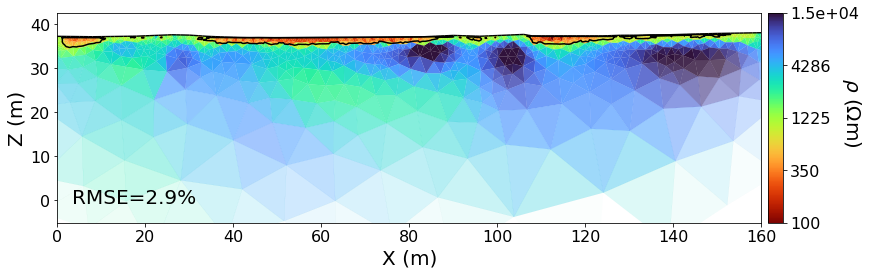

10/04/26 - 12:47:46 - pyGIMLi - INFO - Cache /Users/teddiherringnew/opt/miniconda3/envs/idgsp-mc/lib/python3.9/site-packages/pygimli/physics/ert/ert.py:createGeometricFactors restored (2.9s x 72): /Users/teddiherringnew/Library/Caches/pygimli/4685734810500315786
10/04/26 - 12:47:46 - pyGIMLi - INFO - Found 2 regions.
10/04/26 - 12:47:46 - pyGIMLi - INFO - Region with smallest marker (1) set to background
10/04/26 - 12:47:46 - Core - WARNING - Region Nr: 1  is background and should not get a model transformation.
10/04/26 - 12:47:46 - Core - WARNING - Region Nr: 1  is background and should not get a model control.
10/04/26 - 12:47:46 - pyGIMLi - INFO - Creating forward mesh from region infos.
10/04/26 - 12:47:46 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
10/04/26 - 12:47:46 - pyGIMLi - INFO - Homogeneous starting model set to: 2627.3123000653964


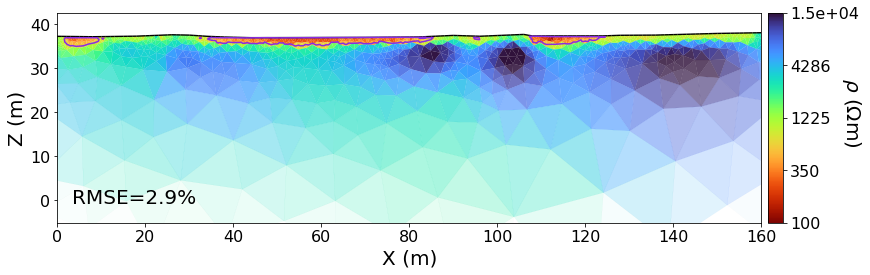

10/04/26 - 12:47:56 - pyGIMLi - INFO - Cache /Users/teddiherringnew/opt/miniconda3/envs/idgsp-mc/lib/python3.9/site-packages/pygimli/physics/ert/ert.py:createGeometricFactors restored (2.9s x 73): /Users/teddiherringnew/Library/Caches/pygimli/4685734810500315786
10/04/26 - 12:47:56 - pyGIMLi - INFO - Found 2 regions.
10/04/26 - 12:47:56 - pyGIMLi - INFO - Region with smallest marker (1) set to background
10/04/26 - 12:47:56 - Core - WARNING - Region Nr: 1  is background and should not get a model transformation.
10/04/26 - 12:47:56 - Core - WARNING - Region Nr: 1  is background and should not get a model control.
10/04/26 - 12:47:56 - pyGIMLi - INFO - Creating forward mesh from region infos.
10/04/26 - 12:47:56 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
10/04/26 - 12:47:56 - pyGIMLi - INFO - Homogeneous starting model set to: 2627.3123000653964


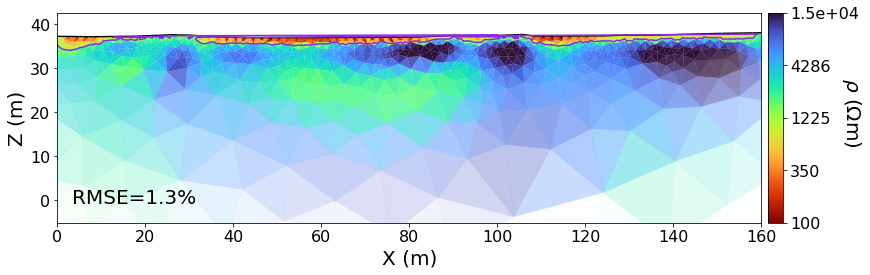

10/04/26 - 12:48:09 - pyGIMLi - INFO - Cache /Users/teddiherringnew/opt/miniconda3/envs/idgsp-mc/lib/python3.9/site-packages/pygimli/physics/ert/ert.py:createGeometricFactors restored (2.9s x 74): /Users/teddiherringnew/Library/Caches/pygimli/4685734810500315786
10/04/26 - 12:48:09 - pyGIMLi - INFO - Found 2 regions.
10/04/26 - 12:48:09 - pyGIMLi - INFO - Region with smallest marker (1) set to background
10/04/26 - 12:48:09 - Core - WARNING - Region Nr: 1  is background and should not get a model transformation.
10/04/26 - 12:48:09 - Core - WARNING - Region Nr: 1  is background and should not get a model control.
10/04/26 - 12:48:09 - pyGIMLi - INFO - Creating forward mesh from region infos.
10/04/26 - 12:48:09 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
10/04/26 - 12:48:09 - pyGIMLi - INFO - Homogeneous starting model set to: 2627.3123000653964


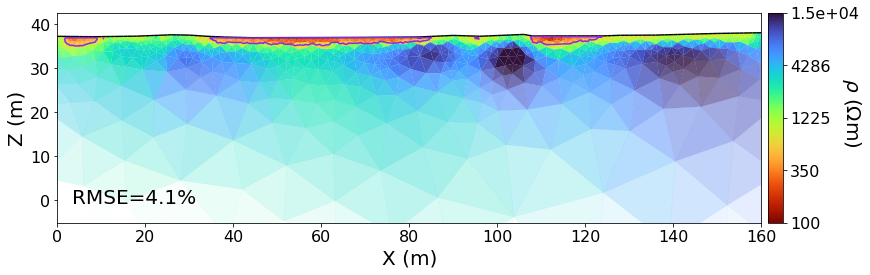

10/04/26 - 12:48:18 - pyGIMLi - INFO - Cache /Users/teddiherringnew/opt/miniconda3/envs/idgsp-mc/lib/python3.9/site-packages/pygimli/physics/ert/ert.py:createGeometricFactors restored (2.9s x 75): /Users/teddiherringnew/Library/Caches/pygimli/4685734810500315786
10/04/26 - 12:48:18 - pyGIMLi - INFO - Found 2 regions.
10/04/26 - 12:48:18 - pyGIMLi - INFO - Region with smallest marker (1) set to background
10/04/26 - 12:48:18 - Core - WARNING - Region Nr: 1  is background and should not get a model transformation.
10/04/26 - 12:48:18 - Core - WARNING - Region Nr: 1  is background and should not get a model control.
10/04/26 - 12:48:18 - pyGIMLi - INFO - Creating forward mesh from region infos.
10/04/26 - 12:48:18 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
10/04/26 - 12:48:18 - pyGIMLi - INFO - Homogeneous starting model set to: 262.73123000653965


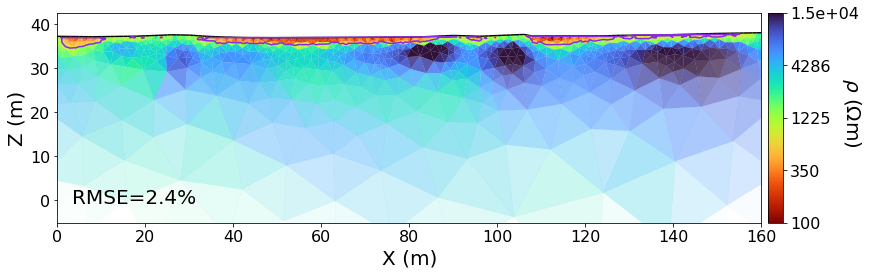

10/04/26 - 12:48:27 - pyGIMLi - INFO - Cache /Users/teddiherringnew/opt/miniconda3/envs/idgsp-mc/lib/python3.9/site-packages/pygimli/physics/ert/ert.py:createGeometricFactors restored (2.9s x 76): /Users/teddiherringnew/Library/Caches/pygimli/4685734810500315786
10/04/26 - 12:48:27 - pyGIMLi - INFO - Found 2 regions.
10/04/26 - 12:48:27 - pyGIMLi - INFO - Region with smallest marker (1) set to background
10/04/26 - 12:48:27 - Core - WARNING - Region Nr: 1  is background and should not get a model transformation.
10/04/26 - 12:48:27 - Core - WARNING - Region Nr: 1  is background and should not get a model control.
10/04/26 - 12:48:27 - pyGIMLi - INFO - Creating forward mesh from region infos.
10/04/26 - 12:48:27 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
10/04/26 - 12:48:27 - pyGIMLi - INFO - Homogeneous starting model set to: 26273.123000653963


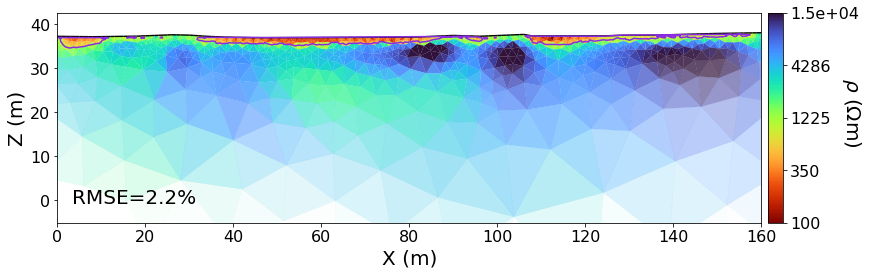

In [6]:

contours_lamp = invert_w_sensitivity(
    pn = '../formatted ert data/summer 2023/',
    fn = '20230829 LAMP2 W160.txt',
    sensorids = None,
    yth=y_th_lamp,
    lam=lam,
    mstart_mult= mstart_mult,
    err_rel=err_rel
)

In [7]:
# get best estimate model
  
j=1

pn = '../formatted ert data/summer 2023/'
fn = '20230829 LAMP2 W160.txt'
sensorids = None

data_raw = ert.load(pn+fn) 

# calculate geometric factor and apparent resistivity if not already in data file

if data_raw.haveData('k')==False:
    data_raw['k'] = ert.createGeometricFactors(data_raw,numerical=True) # include topo in k calculation

if data_raw.haveData('rhoa')==False:
    if data_raw.haveData('r')==False:
        data_raw['r'] = data_raw['u']/data_raw['i']
    data_raw['rhoa'] = data_raw['r']*data_raw['k'] 

# some datasets had problematic cables. if so, remove those data points

if sensorids is not None:
    data_raw.removeSensorIdx(sensorids)

mgr = ert.ERTManager(data_raw)

# inversion parameters

mgr.inv.inv.setBlockyModel(True)

data_raw['err'] = ert.estimateError(
data_raw, 
absoluteError=0.001, 
relativeError=err_rel[j] # % noise
)

# run inversion

mod = mgr.invert(
    data_raw,
    lam=lam[j],
    startModel=np.mean(data_raw['rhoa'])*mstart_mult[j],
)

# getting chi2, rms error

chi2 = mgr.inv.inv.getChi2()
rms = np.sqrt(np.mean(((data_raw['rhoa']-mgr.inv.response)/data_raw['rhoa'])**2))*100



10/04/26 - 12:48:37 - pyGIMLi - INFO - Cache /Users/teddiherringnew/opt/miniconda3/envs/idgsp-mc/lib/python3.9/site-packages/pygimli/physics/ert/ert.py:createGeometricFactors restored (2.9s x 77): /Users/teddiherringnew/Library/Caches/pygimli/4685734810500315786
10/04/26 - 12:48:37 - pyGIMLi - INFO - Found 2 regions.
10/04/26 - 12:48:37 - pyGIMLi - INFO - Region with smallest marker (1) set to background
10/04/26 - 12:48:37 - Core - WARNING - Region Nr: 1  is background and should not get a model transformation.
10/04/26 - 12:48:37 - Core - WARNING - Region Nr: 1  is background and should not get a model control.
10/04/26 - 12:48:37 - pyGIMLi - INFO - Creating forward mesh from region infos.
10/04/26 - 12:48:37 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
10/04/26 - 12:48:37 - pyGIMLi - INFO - Homogeneous starting model set to: 2627.3123000653964


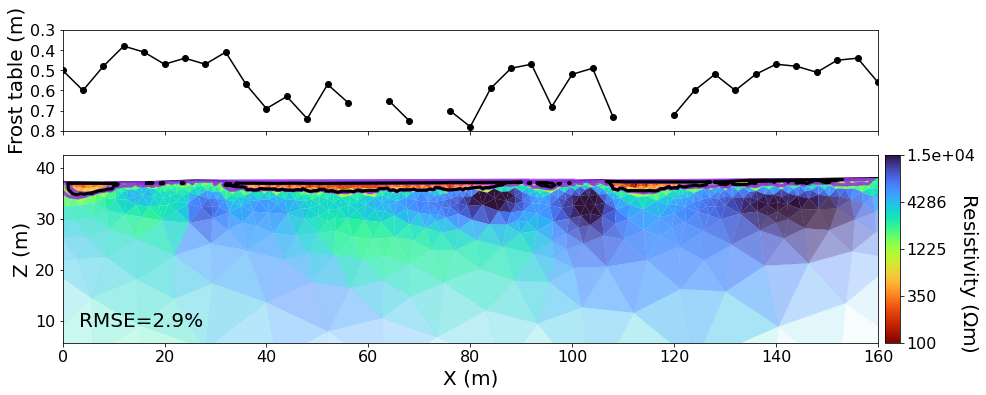

In [8]:

# plot ensemble interpretation

fig1, ax1 = plt.subplots(1,1,figsize=[15,5])

ax, cBar = mgr.showResult(
   mod,
    ax=ax1,
    cMap='turbo_r',
    coverage=mgr.coverage(),
    cMin=100,
    cMax=15000,
    orientation='vertical',
)

# colorbar

cBar.set_label('')
cBar.ax.tick_params(labelsize=fs-4) 
cBar.ax.set_title(r'Resistivity ($\Omega$m)'+ '\n',fontsize=fs,rotation=270, y=-0.06,x=5)

# get axis limits and trim figure automatically

Ex = np.array(data_raw.sensors()).T[0]
Ey = np.array(data_raw.sensors()).T[1]
xmin = min(Ex)
xmax = max(Ex)
ymin = mgr.paraDomain.yMin()
ymax = mgr.paraDomain.yMax()
trim_ymin = ymin + (ymax-ymin)/2
ax1.set_ylim([trim_ymin,ymax+abs(ymax-ymin)*0.07])
ax1.set_xlim([xmin,xmax])

# figure details - electrodes, rms error, axis labels, borehole location

# ax1.plot(Ex,Ey,'ko')
txt = ax1.text(xmin+(xmax-xmin)*0.02,trim_ymin+(ymax-trim_ymin)*0.1,'RMSE=%.1f%%'%(rms),color='k',fontsize=fs)
ax1.tick_params(axis='both', labelsize=fs-4)
ax1.set_xlabel('X (m)',fontsize=fs)
ax1.set_ylabel('Z (m)',fontsize=fs)

for i in range(len(contours_lamp)):
    for j in range(len(contours_lamp[i])):
        if i ==1 :
            ax1.plot(contours_lamp[i][j][:, 0],contours_lamp[i][j][:, 1], color='k',linestyle='-',linewidth=3,alpha=1,zorder=3)
        else:
            ax1.plot(contours_lamp[i][j][:, 0],contours_lamp[i][j][:, 1], color='blueviolet',linestyle='-',linewidth=3,alpha=0.6,zorder=2)

# plot frost table
          
frost_table = pd.read_excel('../frost tables/20230829 LAMP 160.xlsx')   
ft_x = np.array(frost_table['x'])
topo_x = np.array(data_raw.sensors()).T[0]

ft_z = np.array(frost_table['z'])
topo_z = np.array(data_raw.sensors()).T[1]

ft_z = np.where(ft_z==0, np.nan, ft_z) 

ax1 = fig1.add_axes([0.125,0.83,0.755,0.28])
[x,i1,i2] = np.intersect1d(ft_x,topo_x,return_indices=True)
ax1.plot(ft_x,ft_z/100,'ko-')
ax1.set_ylabel('Frost table (m)',fontsize=fs)
plt.gca().invert_yaxis()
ax1.set_xlim([xmin,xmax])
ax1.tick_params(axis='both', labelsize=fs-4)
ax1.tick_params(labelbottom=False)    
ax1.set_ylim([0.8,0.3])
ax1.set_yticks(np.arange(0.3,.81,step=0.1)) 
                
            
fig1.savefig('../inverted results/l1.png',format='png',dpi=dpi,bbox_inches='tight',facecolor='w')


In [9]:
# lamp


zmin = 20
zmax=35

I2 = np.logical_and(
    np.array(mgr.paraDomain.cellCenters()).T[1]<zmax,
    np.array(mgr.paraDomain.cellCenters()).T[1]>zmin
)




print('no peat')

I1 = np.logical_and(
    np.array(mgr.paraDomain.cellCenters()).T[0]>0,
    np.array(mgr.paraDomain.cellCenters()).T[0]<8,
)

I3 = np.logical_and(I1,I2)

print(min(np.array(mod)[I3]))
print(max(np.array(mod)[I3]))
print(np.mean(np.array(mod)[I3]))

print('')


I1 = np.logical_and(
    np.array(mgr.paraDomain.cellCenters()).T[0]>32,
    np.array(mgr.paraDomain.cellCenters()).T[0]<80,
)

I3 = np.logical_and(I1,I2)

print(min(np.array(mod)[I3]))
print(max(np.array(mod)[I3]))
print(np.mean(np.array(mod)[I3]))

print('')



I1 = np.logical_and(
    np.array(mgr.paraDomain.cellCenters()).T[0]>104,
    np.array(mgr.paraDomain.cellCenters()).T[0]<136,
)

I3 = np.logical_and(I1,I2)

print(min(np.array(mod)[I3]))
print(max(np.array(mod)[I3]))
print(np.mean(np.array(mod)[I3]))

print('')

no peat
827.3012506135809
4037.011848867248
2341.4078458604954

1254.6664379583856
11394.46999031406
4212.718710337342

1396.2021380493131
16467.90703233508
6961.760091434826



In [10]:
print('peat')

I1 = np.logical_and(
    np.array(mgr.paraDomain.cellCenters()).T[0]>8,
    np.array(mgr.paraDomain.cellCenters()).T[0]<32,
)


I3 = np.logical_and(I1,I2)

print(min(np.array(mod)[I3]))
print(max(np.array(mod)[I3]))
print(np.mean(np.array(mod)[I3]))

print('')


I1 = np.logical_and(
    np.array(mgr.paraDomain.cellCenters()).T[0]>80,
    np.array(mgr.paraDomain.cellCenters()).T[0]<104,
)

I3 = np.logical_and(I1,I2)

print(min(np.array(mod)[I3]))
print(max(np.array(mod)[I3]))
print(np.mean(np.array(mod)[I3]))

print('')



I1 = np.logical_and(
    np.array(mgr.paraDomain.cellCenters()).T[0]>136,
    np.array(mgr.paraDomain.cellCenters()).T[0]<160,
)


I3 = np.logical_and(I1,I2)

print(min(np.array(mod)[I3]))
print(max(np.array(mod)[I3]))
print(np.mean(np.array(mod)[I3]))

print('')

peat
2067.3227229411805
8373.326361667594
4258.404442955963

2800.2061947766315
19180.440303873587
8602.990301552492

5148.322615833632
15767.694491367563
12115.86291677412

